# Car Purchase Amount — ANN Regression

This notebook:
1. **Explores** the car purchasing dataset
2. **Preprocesses** features and target
3. **Trains** a feedforward ANN to predict car purchase amount
4. **Evaluates** the model (MSE, MAE)

## 1. Imports

In [2]:
# Run this cell once to install dependencies (if you get ModuleNotFoundError)
%pip install scikit-learn tensorflow pandas numpy matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

## 2. Load data

In [14]:
df = pd.read_csv('car_purchasing.csv', encoding='latin-1')
df = df.dropna(how='all')  # drop completely empty rows
print(f"Shape: {df.shape}")
df.head()

Shape: (500, 9)


,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


## 3. Exploratory Data Analysis

In [15]:
numeric_cols = ['gender', 'age', 'annual Salary', 'credit card debt', 'net worth', 'car purchase amount']
print("Data types:\n", df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())
print("\nDescriptive statistics:")
df[numeric_cols].describe().round(2)

Data types:
 customer name           object
customer e-mail         object
country                 object
gender                   int64
age                    float64
annual Salary          float64
credit card debt       float64
net worth              float64
car purchase amount    float64
dtype: object

Missing values: 0

Descriptive statistics:


,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,0.51,46.24,62127.24,9607.65,431475.71,44209.80
std,0.50,7.98,11703.38,3489.19,173536.76,10773.18
min,0.00,20.00,20000.00,100.00,20000.00,9000.00
25%,0.00,40.95,54391.98,7397.52,299824.20,37629.90
50%,1.00,46.05,62915.50,9655.04,426750.12,43997.78
75%,1.00,51.61,70117.86,11798.87,557324.48,51254.71
max,1.00,70.00,100000.00,20000.00,1000000.00,80000.00


Correlation with car purchase amount:
age                 0.632865
annual Salary       0.617862
net worth           0.488580
credit card debt    0.028882
gender             -0.066408
Name: car purchase amount, dtype: float64


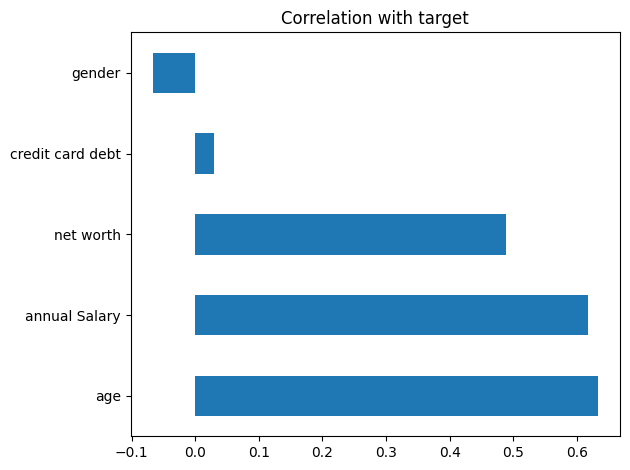

In [16]:
# Correlation with target
corr = df[numeric_cols].corr()['car purchase amount'].drop('car purchase amount').sort_values(ascending=False)
print("Correlation with car purchase amount:")
print(corr)
corr.plot(kind='barh', title='Correlation with target');
plt.tight_layout()
plt.show()

## 4. Preprocessing

- **Features:** gender, age, annual Salary, credit card debt, net worth (drop name, email, country)
- **Target:** car purchase amount
- Scale features with `StandardScaler`

In [17]:
feature_cols = ['gender', 'age', 'annual Salary', 'credit card debt', 'net worth']
target_col = 'car purchase amount'

X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop any rows with missing target
mask = y.notna()
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale target so the ANN trains on a similar scale as inputs
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

print(f"Train: {X_train_scaled.shape[0]} samples, Test: {X_test_scaled.shape[0]} samples")
print(f"Features: {feature_cols}")

Train: 400 samples, Test: 100 samples
Features: ['gender', 'age', 'annual Salary', 'credit card debt', 'net worth']


## 5. Build ANN model

In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model

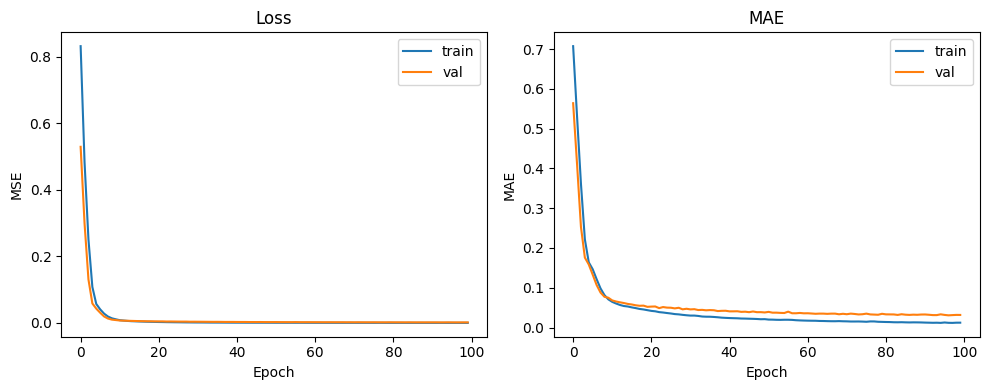

In [19]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE')
plt.tight_layout()
plt.show()

## 7. Evaluate on test set

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Test MSE:  163180.80
Test MAE: 306.04


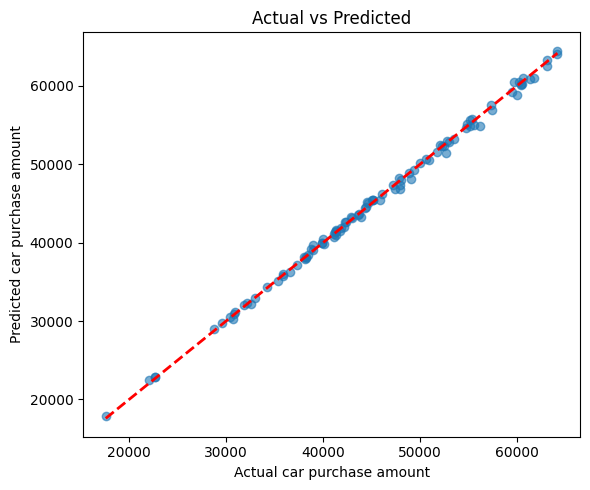

In [20]:
# Predict in scaled space, then inverse-transform to original scale
y_pred_scaled = model.predict(X_test_scaled).flatten()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Metrics in original scale (dollars)
mse = np.mean((y_test.values - y_pred) ** 2)
mae = np.mean(np.abs(y_test.values - y_pred))
print(f"Test MSE:  {mse:.2f}")
print(f"Test MAE: {mae:.2f}")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual car purchase amount')
plt.ylabel('Predicted car purchase amount')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()